In [1]:
import multiprocessing as mp
from gensim.corpora import Dictionary
import spacy    
from gensim.models import Phrases, LdaModel, LdaMulticore, CoherenceModel
import pandas as pd
import matplotlib.pyplot as plt
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from transformers import pipeline

/opt/miniconda3/envs/windygraph/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
RANDOM_STATE = 0
SPACY_MODEL = "en_core_web_md"
CPU_COUNT = mp.cpu_count()

In [20]:
data = pd.read_csv("../data/processed_review_data.csv")

In [6]:
data.head()

,restaurant_id,review_id,rating,text,time_created,user_id,user_name,bert_sentiment,bert_score,mapped_sentiment,weighted_score,days_since_review,recency_score,normalized_rating
0,7E0GO6fb7KIGAd9js7mDPg,E751zhSQwwPC0Ez9L4XjMw,5,latise was top tier she was helping us when ou...,2025-03-29 16:12:03,coyhRIEbGDSGoNfhSweExQ,Tatyana M.,3 stars,0.247331,neutral,0.897149,41.299981,0.994297,0.8
1,7E0GO6fb7KIGAd9js7mDPg,la35rIgA4ovGsORoadkEag,4,"I love the food, it is always hot and good, bu...",2025-03-29 14:46:42,BTT0rftnl3TYC9J8FhAMHQ,Magic S.,3 stars,0.529116,neutral,0.797145,41.359252,0.994289,0.6
2,7E0GO6fb7KIGAd9js7mDPg,kuh0Nhj4llWnQlMB2SAs9Q,1,I left Jamaican Jerk Villa on 79th Street afte...,2025-01-04 23:17:47,TK7dZsvFTPPRL7f9CeYyhQ,Kara K.,1 star,0.797877,negative,0.491370,125.004333,0.982739,0.0
3,NYY3GwZTg332dkhs8JJnlg,tnTr-WiNsgCxJI_PmhYf_w,5,"YUMMY! \n\nIndividual 9"" Cheese Pizza\nPineapp...",2025-01-20 17:31:38,EOSsvFLMJCTYMhcrlJkVag,Fredrick B.,5 stars,0.484487,positive,0.892458,109.244715,0.984915,0.8
4,NYY3GwZTg332dkhs8JJnlg,666atuVPmbAW2sZmcJY9MQ,2,Terrible Service on NYE of 2025 \nThey were ba...,2025-01-05 10:25:22,k5vKB9luZv4J0t1haZTG0A,Deidra A.,1 star,0.669533,negative,0.591402,124.540733,0.982803,0.2


In [21]:
def clean_text(corpus, spacy_pipeline, as_string=True, n_proc=2, batch_size=1000):
    """
    Cleans a sequence of text by applying some simple processing techniques.

    Args:
        corpus (Iterable): a sequence of text to be processed
        spacy_pipeline: the Spacy pipeline object for processing text
        n_proc (int): the number of processors to use for parallel processing
        batch_size (int): the number of texts to process in a single batch

    Returns:
        clean_sequence (list): a cleaned version of the original text
    """
    # container to store cleaned documents
    corpus_clean = []

    for doc in spacy_pipeline.pipe(
        corpus,
        disable=["ner"],
        n_process=n_proc,
        batch_size=batch_size
    ):

        # container for cleaned document tokens
        doc_tokens = [
            token.lemma_.lower()
            for token in doc
            if not token.is_stop and token.is_alpha and (len(token) > 1) and token.pos_ in ("NOUN", "VERB") # should consider if these are appropriate
        ]
        
        if as_string:
            corpus_clean.append(" ".join(doc_tokens))
        else:
            corpus_clean.append(doc_tokens)

    return corpus_clean

In [18]:
# loading spacy model
nlp = spacy.load(SPACY_MODEL)

In [22]:
# apply cleaning to dataC
normalized_corpus = clean_text(
    corpus=data["text"].tolist(),
    spacy_pipeline=nlp,
    as_string=False
)

In [11]:
print(data["text"][0])
print(normalized_corpus[0])

latise was top tier she was helping us when our own waitress ain't want toooo. yall need to promote her to being a manager
['tier', 'help', 'waitress', 'want', 'toooo', 'need', 'promote', 'manager']


In [24]:
# training the phrases to find bigrams
bigram_phraser = Phrases(normalized_corpus) # this might require some eda, to decide min_count

# adding bigrams to the original unigram data
for idx in range(len(normalized_corpus)):
    for phrase in bigram_phraser[normalized_corpus[idx]]:
        if '_' in phrase:
            # phrase is a bigram, add to document.
            normalized_corpus[idx].append(phrase)

In [ ]:
# a dictiohary is the mapping of an id to a word
dictionary = Dictionary(normalized_corpus)

# Filter out words that occur less than 1% of documents, or more than 50% of the documents.
# dictionary.filter_extremes(no_below=10, no_above=0.7)

In [26]:
[(token, idx) for token, idx in dictionary.token2id.items()][:10]

[('help', 0),
 ('manager', 1),
 ('need', 2),
 ('promote', 3),
 ('tier', 4),
 ('toooo', 5),
 ('waitress', 6),
 ('want', 7),
 ('believe', 8),
 ('food', 9)]

In [27]:
corpus = [dictionary.doc2bow(doc) for doc in normalized_corpus]

print('Number of unique tokens: %d' % len(dictionary))
print('Number of documents: %d' % len(corpus))

Number of unique tokens: 6340
Number of documents: 13931


In [ ]:
# min_topics = 2
# max_topics = 50
# step_size = 1
# topics_range = range(min_topics, max_topics + 1, step_size)
# chunksize = 10 # number of documents to be used in each training chunk
# passes = 20 # epochs
# iterations = 400 # how many times the model iterates over each document during a single pass / epoch
# eval_every = 0

# coherence_scores = []

# for num_topics in topics_range:
#     model = LdaMulticore(
#         corpus=corpus,
#         id2word=dictionary,
#         chunksize=chunksize,
#         alpha='symmetric',
#         eta='auto',
#         iterations=iterations,
#         num_topics=num_topics,
#         passes=passes,
#         eval_every=eval_every,
#         workers=3,
#         random_state=RANDOM_STATE
#     )
    
#     # Compute Coherence Score
#     coherence_model = CoherenceModel(model=model, texts=normalized_corpus, dictionary=dictionary, coherence='c_v')
#     coherence_score = coherence_model.get_coherence()
#     coherence_scores.append(coherence_score)

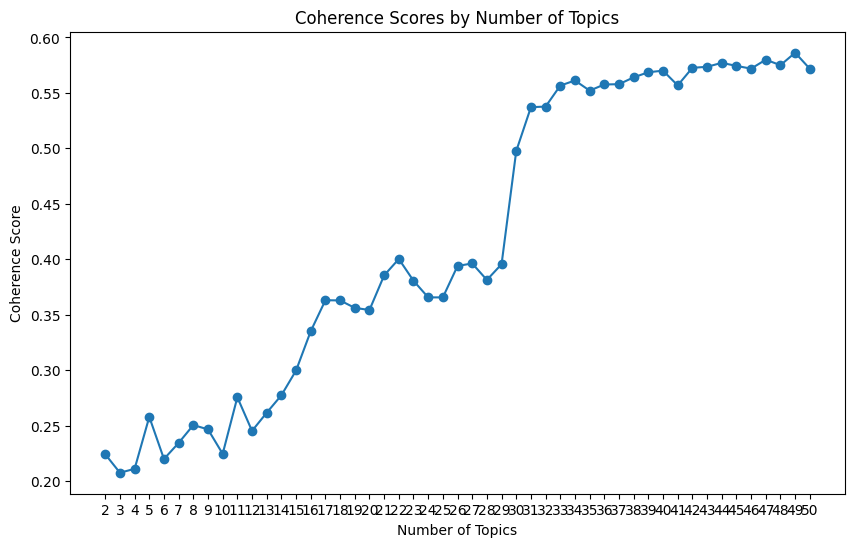

In [ ]:

# plt.figure(figsize=(10, 6))
# plt.plot(topics_range, coherence_scores, marker='o')
# plt.title("Coherence Scores by Number of Topics")
# plt.xlabel("Number of Topics")
# plt.ylabel("Coherence Score")
# plt.xticks(topics_range)
# plt.show()

In [28]:
num_topics = 33 # the number of topics we want the model to return
chunksize = 500 # number of documents to be used in each training chunk
passes = 20 # epochs
iterations = 150 # how many times the model iterates over each document during a single pass / epoch
eval_every = 0  # affects speed and quality of the model, can increase for larger datasets

model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    chunksize=chunksize,
    alpha="auto",
    eta='auto',
    iterations=iterations,
    num_topics=num_topics,
    passes=passes,
    eval_every=eval_every,
    random_state=RANDOM_STATE
)

In [29]:
model.show_topics(num_words=30)
# model.show_topics()

[(7,
  '0.101*"kid" + 0.091*"bartender" + 0.072*"shrimp" + 0.059*"pastry" + 0.051*"stand" + 0.046*"hang" + 0.043*"snack" + 0.039*"watch" + 0.035*"water" + 0.034*"hold" + 0.029*"expectation" + 0.029*"corn" + 0.027*"crab" + 0.027*"grow" + 0.026*"tonight" + 0.024*"pleasure" + 0.021*"perfection" + 0.018*"elote" + 0.017*"provide" + 0.012*"chili" + 0.011*"handful" + 0.011*"leg" + 0.010*"refill" + 0.009*"broccoli" + 0.009*"start_say" + 0.007*"crab_leg" + 0.006*"round" + 0.006*"report" + 0.005*"code" + 0.003*"cheat"'),
 (31,
  '0.119*"table" + 0.105*"minute" + 0.068*"pack" + 0.065*"wine" + 0.060*"wait_minute" + 0.039*"crowd" + 0.033*"answer_phone" + 0.030*"building" + 0.029*"answer" + 0.025*"driver" + 0.022*"selection_wine" + 0.022*"wait" + 0.021*"festival" + 0.020*"cupcake" + 0.020*"environment" + 0.019*"plan" + 0.019*"package" + 0.017*"craving" + 0.016*"refuse" + 0.014*"medium" + 0.013*"study" + 0.011*"spirit" + 0.011*"warm" + 0.009*"finish" + 0.009*"blow" + 0.009*"traffic" + 0.009*"catering

In [ ]:
topics = model.show_topics(num_topics=num_topics, num_words=30, formatted=False)

topic_data = []

for topic_id, word_probs in topics:
    words = [word for word, _ in word_probs]
    probs = [round(prob, 4) for _, prob in word_probs]
    topic_keywords = ", ".join(words)
    topic_data.append({
        "topic_id": topic_id,
        "keywords": topic_keywords,
        "keywords_list": words,
        "weights": probs
    })

df_topics = pd.DataFrame(topic_data)

In [31]:
df_topics.to_csv("df_topics.csv", index=False)

In [32]:
topic_labels = {
    0:  "Restaurant Logistics & Family-Owned Operations",       # restaurant, taco, family, business, close, deliver, family_own, dine, welcome, own
    1:  "Group Visits & Cookie Desserts",                        # find, feel, group, cookie, box, job, dive, smell, word, deserve
    2:  "Pizza Quality & Hidden Gems",                           # pizza, dish, game, gem, hide_gem, hide, accommodate, joint, crust, tv
    3:  "Work Dinner & Delivery Services",                       # work, people, delivery, selection, bring, liquor, people_work, watch_game, register, guess
    4:  "Neighborhood Coffee Shops & Cash Handling",              # neighborhood, recommend, shop, coffee_shop, change, live_neighborhood, money, return, cash, coffee
    5:  "Drinks & Sushi Rolls Weekend Brunch",                   # drink, ask, rice, roll, sushi, weekend, fish, bite, bean, kind
    6:  "Coffee, Meat Plates & Ambience",                        # know, coffee, meat, see, offer, drive, pay, afternoon, point, receive
    7:  "Snacks & Bartender Service",                            # kid, bartender, shrimp, pastry, stand, hang, snack, watch, water, hold
    8:  "Burger & Egg Sandwich Experiences",                     # burger, cheese, egg, fill, onion, grab_drink, celebrate, potato, trip, sausage
    9:  "Staff & Location Greetings",                            # staff, location, give, locate, couple, home, cafe, hit, month, greet
    10: "Portion Sizes & Quality Expectations",                  # want, think, quality, sit, size, talk, portion_size, park, appetizer, list
    11: "Night Dining Vibes & Walking Tours",                    # eat, night, enjoy, walk, dinner, vibe, have, man, diner, spend
    12: "Review Writing & City Exploration",                     # review, take, city, write_review, move, write, piece, care, lemon_pepper, pepper
    13: "Lunch Options & Dog-Friendly Seating",                  # lunch, option, seating, dog, establishment, special, product, life, window, number
    14: "Grocery Stores & Taco/Burrito Choices",                 # grocery_store, steak, pick, grab, grocery, burrito, steak_taco, arrive, speak, market
    15: "Ice Cream & Brunch Spot Atmosphere",                    # ice_cream, ice, live, cream, bread, play, brunch, lady, worker, hear
    16: "Store Visits & Pizza Slice Management",                 # go, year, store, way, employee, make, event, use, miss, corner
    17: "Phone Orders & Gas Station Eats",                       # tell, meal, call, start, let, street, leave, bowl, min, summer
    18: "Parking & Party Cake Celebrations",                     # lot, need, parking, party, cake, parking_lot, birthday, sell, soup, house
    19: "Love & Donut Purchases",                                # love, space, deal, husband, donut, app, wife, purchase, invite, choice
    20: "Menu Design & Music/Decor Ambience",                    # menu, fry, music, style, slice, chocolate, season, lack_flavor, lack, style_pizza
    21: "Dinner Reservations & Wait Staff",                      # door, cook, pm, reservation, evening, waitress, wait_hour, chip, half, pasta
    22: "Bakery Items & Daytime Treats",                         # stop, day, taste, buy, item, person, thank, happen, bakery, include
    23: "Food & Service Experience Highlights",                  # food, service, customer_service, experience, customer, star, ambiance, decide_try, treat, counter
    24: "Order Accuracy & Wing/Salad Takeout",                   # order, sauce, wing, salad, takeout, tea, meet, wait_line, set, chance
    25: "Price Points & Bar Beverage Selection",                 # price, bar, look, flavor, say, owner, beer, portion, charge, wish
    26: "Hole-in-the-Wall Gems & Date Night Spots",              # check, bit, guy, seat, hole_wall, date_night, date, art, wall, patio
    27: "Waiting Lines & Dining Room Decor",                     # wait, like, thing, week, line, believe, dining_room, decor, room, decide_check
    28: "Trying New Spots & Variety Tasting",                    # try, spot, decide, open, variety, hand, plenty, crave, stay, pass
    29: "Chicken Sandwiches & Wing Ordering",                    # chicken, sandwich, hour, expect, beef, end, chicken_sandwich, chicken_wing, remember, sign
    30: "Place Visits & Music/Cocktail Bars",                    # place, time, come, get, visit, friend, disappoint, run, morning, town
    31: "Table Service & Wine/Crowd Atmosphere",                 # table, minute, pack, wine, wait_minute, crowd, answer_phone, building, answer, driver
    32: "Area Atmosphere & Breakfast Cuisine"                    # area, breakfast, serve, atmosphere, today, server, fun, dining, hope, cuisine
}
topic_df = (
    pd.DataFrame.from_dict(topic_labels, orient='index', columns=['topic_label'])
      .reset_index()
      .rename(columns={'index':'topic_id'})
)

print(topic_df)

    topic_id                                     topic_label
0          0  Restaurant Logistics & Family-Owned Operations
1          1                  Group Visits & Cookie Desserts
2          2                     Pizza Quality & Hidden Gems
3          3                 Work Dinner & Delivery Services
4          4       Neighborhood Coffee Shops & Cash Handling
5          5             Drinks & Sushi Rolls Weekend Brunch
6          6                  Coffee, Meat Plates & Ambience
7          7                      Snacks & Bartender Service
8          8               Burger & Egg Sandwich Experiences
9          9                      Staff & Location Greetings
10        10            Portion Sizes & Quality Expectations
11        11              Night Dining Vibes & Walking Tours
12        12               Review Writing & City Exploration
13        13            Lunch Options & Dog-Friendly Seating
14        14           Grocery Stores & Taco/Burrito Choices
15        15            

In [ ]:
dominant_topics = []
for bow in corpus:
    topics_probs = model.get_document_topics(bow)
    topic_id, prob = max(topics_probs, key=lambda x: x[1])
    dominant_topics.append(topic_id)
    
dataTopics = data.copy()
dataTopics['topic_id'] = dominant_topics

dataTopics['topic_label'] = dataTopics['topic_id'].map(topic_labels)
print(dataTopics)

                restaurant_id               review_id  rating  \
0      7E0GO6fb7KIGAd9js7mDPg  E751zhSQwwPC0Ez9L4XjMw       5   
1      7E0GO6fb7KIGAd9js7mDPg  la35rIgA4ovGsORoadkEag       4   
2      7E0GO6fb7KIGAd9js7mDPg  kuh0Nhj4llWnQlMB2SAs9Q       1   
3      NYY3GwZTg332dkhs8JJnlg  tnTr-WiNsgCxJI_PmhYf_w       5   
4      NYY3GwZTg332dkhs8JJnlg  666atuVPmbAW2sZmcJY9MQ       2   
...                       ...                     ...     ...   
13926  LQOMDnwbJLsqKNnGNCeNWA  6OfaFDrYcAA7a-xJFbOTDA       4   
13927  LQOMDnwbJLsqKNnGNCeNWA  V6MAjxLIzvpSlfWO-UrU2g       1   
13928  fcHpivCQIeQekyJ3TVitZQ  4nPFZZunX3Pw0Frzid-3mg       5   
13929  fcHpivCQIeQekyJ3TVitZQ  uDxy5HhGTM6BgXumUu1Izw       5   
13930  fcHpivCQIeQekyJ3TVitZQ  fBw4XnUOMUX-NRM9K6QKDQ       5   

                                                    text         time_created  \
0      latise was top tier she was helping us when ou...  2025-03-29 16:12:03   
1      I love the food, it is always hot and good, bu... 

In [40]:
data["prediction"] = data["mapped_sentiment"].map({"positive":1, "neutral":0, "negative":-1})
nlp = spacy.load(SPACY_MODEL)
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))



In [7]:
import importlib
import aspect_ext
importlib.reload(aspect_ext)
from aspect_ext import aspects_extraction
data = data.rename(columns={"text":"review"})
aspects_adj = aspects_extraction(data,stop_words,lemmatizer,nlp)

In [8]:
aspects_adj

,aspect,adjective,aspect_adj,restaurant_id,review_id
0,tier,top,top tier,7E0GO6fb7KIGAd9js7mDPg,E751zhSQwwPC0Ez9L4XjMw
1,waitress,own,own waitress,7E0GO6fb7KIGAd9js7mDPg,E751zhSQwwPC0Ez9L4XjMw
2,food,hot,hot food,7E0GO6fb7KIGAd9js7mDPg,la35rIgA4ovGsORoadkEag
3,food,good,good food,7E0GO6fb7KIGAd9js7mDPg,la35rIgA4ovGsORoadkEag
4,time,big,big time,7E0GO6fb7KIGAd9js7mDPg,la35rIgA4ovGsORoadkEag
...,...,...,...,...,...
35024,laugh,best,best laugh,fcHpivCQIeQekyJ3TVitZQ,uDxy5HhGTM6BgXumUu1Izw
35025,bar,best,best bar,fcHpivCQIeQekyJ3TVitZQ,fBw4XnUOMUX-NRM9K6QKDQ
35026,staff,nice,nice staff,fcHpivCQIeQekyJ3TVitZQ,fBw4XnUOMUX-NRM9K6QKDQ
35027,mile,extra,extra mile,fcHpivCQIeQekyJ3TVitZQ,fBw4XnUOMUX-NRM9K6QKDQ


In [43]:
sentiment_pipeline = pipeline("sentiment-analysis")

texts = aspects_adj['aspect_adj'].tolist()
results = sentiment_pipeline(texts, batch_size=32)

scores = [r['score'] for r in results]
labels = [r['label'].lower() for r in results]

aspects_adj['sentiment_score'] = scores
aspects_adj['sentiment_label'] = labels

neutral_mask = aspects_adj['sentiment_score'] < 0.9
aspects_adj.loc[neutral_mask, 'sentiment_label'] = 'neutral'

print(aspects_adj.head())

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use mps:0


     aspect adjective    aspect_adj           restaurant_id  \
0      tier       top      top tier  7E0GO6fb7KIGAd9js7mDPg   
1  waitress       own  own waitress  7E0GO6fb7KIGAd9js7mDPg   
2      food       hot      hot food  7E0GO6fb7KIGAd9js7mDPg   
3      food      good     good food  7E0GO6fb7KIGAd9js7mDPg   
4      time       big      big time  7E0GO6fb7KIGAd9js7mDPg   

                review_id  sentiment_score sentiment_label  
0  E751zhSQwwPC0Ez9L4XjMw         0.999295        positive  
1  E751zhSQwwPC0Ez9L4XjMw         0.941403        positive  
2  la35rIgA4ovGsORoadkEag         0.999691        positive  
3  la35rIgA4ovGsORoadkEag         0.999863        positive  
4  la35rIgA4ovGsORoadkEag         0.999358        positive  


In [42]:
aspects_adj[aspects_adj['sentiment_score'] < 0.95]

,aspect,adjective,aspect_adj,restaurant_id,review_id,sentiment_score,sentiment_label
1,waitress,own,own waitress,7E0GO6fb7KIGAd9js7mDPg,E751zhSQwwPC0Ez9L4XjMw,0.941403,positive
5,jerk villa,jamaican,jamaican jerk villa,7E0GO6fb7KIGAd9js7mDPg,kuh0Nhj4llWnQlMB2SAs9Q,0.944670,negative
12,pizza onion,individual,individual pizza onion,NYY3GwZTg332dkhs8JJnlg,tnTr-WiNsgCxJI_PmhYf_w,0.715115,neutral
15,inn pizza,frozen,frozen inn pizza,NYY3GwZTg332dkhs8JJnlg,1J7zOkWc5V1jVcdDf4hlKA,0.661849,neutral
21,week,long,long week,zPZuFYVeu6KfQpupYhP1LQ,F3uelpYobYrXgMDdKKclUA,0.806078,neutral
...,...,...,...,...,...,...,...
34992,ordering,online,online ordering,iKrG71Xe6DRIH268iXqaow,De_6MlZ-pDabcyohyWa9Ig,0.829539,neutral
34999,delicacy,local,local delicacy,iKrG71Xe6DRIH268iXqaow,q2INlzUhn7E3EN0wdnaQ6Q,0.938486,negative
35003,order,online,online order,UUrzfbDKeZvEPlgbo7S6_g,c6pCaIaZLMoZ1cg9KJmweQ,0.746882,neutral
35006,out,fast,fast out,UUrzfbDKeZvEPlgbo7S6_g,c6pCaIaZLMoZ1cg9KJmweQ,0.679975,neutral


In [45]:
dataTopics.to_csv("../data/reviewTopics.csv", index=False)
aspects_adj.to_csv("../data/absa.csv", index=False)